In [1]:
import xarray as xr
import matplotlib.pyplot as plt

In [2]:
file_path=r'B3GRD_d03.nc'
ds=xr.open_dataset(file_path)
ds

<frozen importlib._bootstrap>:241: RuntimeWarning: numpy.ndarray size changed, may indicate binary incompatibility. Expected 16 from C header, got 96 from PyObject


<xarray.Dataset> Size: 6MB
Dimensions:           (TSTEP: 1, VAR: 77, DATE-TIME: 2, LAY: 1, ROW: 127,
                       COL: 151)
Dimensions without coordinates: TSTEP, VAR, DATE-TIME, LAY, ROW, COL
Data variables: (12/78)
    TFLAG             (TSTEP, VAR, DATE-TIME) int32 616B ...
    AVG_ISOPS         (TSTEP, LAY, ROW, COL) float32 77kB ...
    AVG_MBOS          (TSTEP, LAY, ROW, COL) float32 77kB ...
    AVG_METHS         (TSTEP, LAY, ROW, COL) float32 77kB ...
    AVG_APINS         (TSTEP, LAY, ROW, COL) float32 77kB ...
    AVG_BPINS         (TSTEP, LAY, ROW, COL) float32 77kB ...
    ...                ...
    LAI_ISOPW         (TSTEP, LAY, ROW, COL) float32 77kB ...
    LAI_MBOW          (TSTEP, LAY, ROW, COL) float32 77kB ...
    LAI_METHW         (TSTEP, LAY, ROW, COL) float32 77kB ...
    AVG_NOAG_GROW     (TSTEP, LAY, ROW, COL) float32 77kB ...
    AVG_NOAG_NONGROW  (TSTEP, LAY, ROW, COL) float32 77kB ...
    AVG_NONONAG       (TSTEP, LAY, ROW, COL) float32 77kB ...
Attributes: (12/33)
    IOAPI_VERSION:  ioapi-3.2: $Id: init3.F90 185 2020-08-28 16:49:45Z coats $
    EXEC_ID:        ????????????????
    FTYPE:          1
    CDATE:          2026181
    CTIME:          23334
    WDATE:          2026181
    ...             ...
    VGLVLS:         [-9999. -9999.]
    GDNAM:          d03_GRID        
    UPNAM:          NORMBEIS370
    VAR-LIST:       AVG_ISOPS       AVG_MBOS        AVG_METHS       AVG_APINS...
    FILEDESC:       BEIS3 normalized emissions values.
    HISTORY:

In [13]:
ds.AVG_APINS

<xarray.DataArray 'AVG_APINS' (TSTEP: 1, LAY: 1, ROW: 127, COL: 151)> Size: 77kB
[19177 values with dtype=float32]
Dimensions without coordinates: TSTEP, LAY, ROW, COL
Attributes:
    long_name:  AVG_APINS       
    var_desc:   normalized emissions
    units:      g C/m²-hr

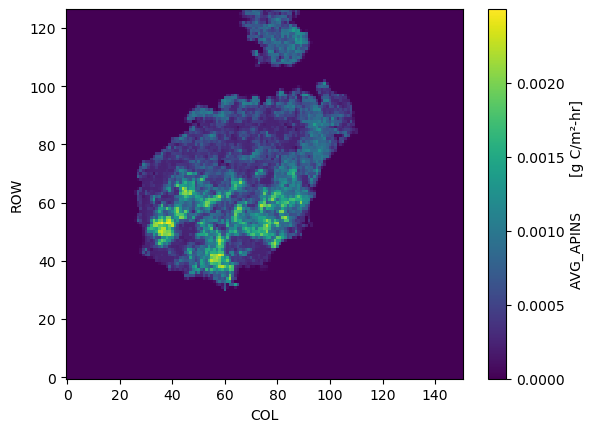

In [12]:
ds['AVG_APINS'].isel(TSTEP=0,LAY=0).plot()
plt.show()

In [5]:
ds.close()

### 检查 B3GRD_d03 文件的异常(LAI)问题

#### 测试 LAI 异常的 d03 文件

In [31]:
import numpy as np
import netCDF4 as nc

# 读取 B3GRD
f = nc.Dataset('B3GRD_d03.nc', 'r')

# 查找 LAI 变量（变量名可能是 LAI、LAI_S、LAI_W 或带植被类型后缀）
lai_vars = [v for v in f.variables.keys() if 'lai' in v.lower()]
print("LAI 变量:", lai_vars)

for vname in lai_vars:
    var = f.variables[vname][:]
    # 去掉时间维度，取二维平面
    while var.ndim > 2:
        var = var[0]
    
    # 检查 (C,R)=(1,2) 即 [ROW=1, COL=0]（0-based）
    #val = var[1, 0]
    val=var
    print(f"\n变量 {vname}:")
    print(f"  (C,R)=(1,2) 的值: {val}")
    print(f"  NaN 数量: {np.count_nonzero(np.isnan(var))}")
    print(f"  Inf 数量: {np.count_nonzero(np.isinf(var))}")
    print(f"  <0 数量: {np.count_nonzero(var < 0)}")
    print(f"  >20 数量: {np.count_nonzero(var > 20)}")
    print(f"  min: {np.nanmin(var):.4f}, max: {np.nanmax(var):.4f}")

f.close()

LAI 变量: ['LAI_ISOPS', 'LAI_MBOS', 'LAI_METHS', 'LAI_ISOPW', 'LAI_MBOW', 'LAI_METHW']

变量 LAI_ISOPS:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  NaN 数量: 0
  Inf 数量: 0
  <0 数量: 0
  >20 数量: 0
  min: 0.0000, max: 6.0000

变量 LAI_MBOS:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  NaN 数量: 0
  Inf 数量: 0
  <0 数量: 0
  >20 数量: 0
  min: 0.0000, max: 6.0000

变量 LAI_METHS:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  NaN 数量: 0
  Inf 数量: 0
  <0 数量: 0
  >20 数量: 0
  min: 0.0000, max: 6.0000

变量 LAI_ISOPW:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ...

In [14]:
import numpy as np
import netCDF4 as nc

# 读取 B3GRD
f = nc.Dataset('B3GRD_d03.nc', 'r')

# 查找 LAI 变量（变量名可能是 LAI、LAI_S、LAI_W 或带植被类型后缀）
lai_vars = [v for v in f.variables.keys() if 'lai' in v.lower()]
print("LAI 变量:", lai_vars)

for vname in lai_vars:
    var = f.variables[vname][:]
    # 去掉时间维度，取二维平面
    while var.ndim > 2:
        var = var[0]
    
    # 检查 (C,R)=(1,2) 即 [ROW=1, COL=0]（0-based）
    #val = var[1, 0]
    val=var
    print(f"\n变量 {vname}:")
    print(f"  (C,R)=(1,2) 的值: {val}")
    print(f"  NaN 数量: {np.count_nonzero(np.isnan(var))}")
    print(f"  Inf 数量: {np.count_nonzero(np.isinf(var))}")
    print(f"  <0 数量: {np.count_nonzero(var < 0)}")
    print(f"  >20 数量: {np.count_nonzero(var > 20)}")
    print(f"  min: {np.nanmin(var):.4f}, max: {np.nanmax(var):.4f}")

f.close()

LAI 变量: ['LAI_ISOPS', 'LAI_MBOS', 'LAI_METHS', 'LAI_ISOPW', 'LAI_MBOW', 'LAI_METHW']

变量 LAI_ISOPS:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  NaN 数量: 0
  Inf 数量: 0
  <0 数量: 0
  >20 数量: 0
  min: 0.0000, max: 6.0000

变量 LAI_MBOS:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  NaN 数量: 0
  Inf 数量: 0
  <0 数量: 0
  >20 数量: 0
  min: 0.0000, max: 6.0000

变量 LAI_METHS:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
  NaN 数量: 0
  Inf 数量: 0
  <0 数量: 0
  >20 数量: 0
  min: 0.0000, max: 6.0000

变量 LAI_ISOPW:
  (C,R)=(1,2) 的值: [[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ...

#### 检验正常的d02文件

In [6]:
import numpy as np
import netCDF4 as nc

# 读取 B3GRD
f = nc.Dataset('B3GRD_d02.nc', 'r')

# 查找 LAI 变量（变量名可能是 LAI、LAI_S、LAI_W 或带植被类型后缀）
lai_vars = [v for v in f.variables.keys() if 'lai' in v.lower()]
print("LAI 变量:", lai_vars)

for vname in lai_vars:
    var = f.variables[vname][:]
    # 去掉时间维度，取二维平面
    while var.ndim > 2:
        var = var[0]
    
    # 检查 (C,R)=(1,2) 即 [ROW=1, COL=0]（0-based）
    #val = var[1, 0]
    val=var
    print(f"\n变量 {vname}:")
    print(f"  (C,R)=(1,2) 的值: {val}")
    print(f"  NaN 数量: {np.count_nonzero(np.isnan(var))}")
    print(f"  Inf 数量: {np.count_nonzero(np.isinf(var))}")
    print(f"  <0 数量: {np.count_nonzero(var < 0)}")
    print(f"  >20 数量: {np.count_nonzero(var > 20)}")
    print(f"  min: {np.nanmin(var):.4f}, max: {np.nanmax(var):.4f}")

f.close()

LAI 变量: ['LAI_ISOPS', 'LAI_MBOS', 'LAI_METHS', 'LAI_ISOPW', 'LAI_MBOW', 'LAI_METHW']

变量 LAI_ISOPS:
  (C,R)=(1,2) 的值: [[5.6052e-45 0.0000e+00 1.4013e-45 ... 1.4013e-45 0.0000e+00 0.0000e+00]
 [0.0000e+00 5.6052e-45 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.1429e-41 1.1471e-41 1.2612e-42 ... 1.4013e-45 0.0000e+00 0.0000e+00]
 ...
 [1.4013e-45 0.0000e+00 0.0000e+00 ... 0.0000e+00 0.0000e+00 1.7796e-43]
 [0.0000e+00 1.4013e-45 0.0000e+00 ... 0.0000e+00 5.1981e-41 5.2027e-41]
 [1.2822e-42 1.6199e-42 0.0000e+00 ... 0.0000e+00 0.0000e+00 5.6052e-45]]
  NaN 数量: 0
  Inf 数量: 0
  <0 数量: 0
  >20 数量: 0
  min: 0.0000, max: 0.0000

变量 LAI_MBOS:
  (C,R)=(1,2) 的值: [[5.6052e-45 0.0000e+00 1.4013e-45 ... 1.4013e-45 0.0000e+00 0.0000e+00]
 [0.0000e+00 5.6052e-45 0.0000e+00 ... 0.0000e+00 0.0000e+00 0.0000e+00]
 [1.1429e-41 1.1471e-41 1.2612e-42 ... 1.4013e-45 0.0000e+00 0.0000e+00]
 ...
 [1.4013e-45 0.0000e+00 0.0000e+00 ... 0.0000e+00 0.0000e+00 1.7796e-43]
 [0.0000e+00 1.4013e-45 0.0000e+00 

#### 测试一下原始的 wrfbiochemi_d03 文件

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
# 读取 wrfbiochemi_d03 文件
with xr.open_dataset(r'D:\HPC_Projects\WRF-CMAQ\20260630\wrfbiochemi_to_cmaq\wrfbiochemi_d03') as ds:
    print(ds.variables.keys())

KeysView(Frozen({'Times': <xarray.Variable (Time: 1)> Size: 19B
[1 values with dtype=|S19], 'MSEBIO_ISOP': <xarray.Variable (Time: 1, south_north: 129, west_east: 153)> Size: 79kB
[19737 values with dtype=float32]
Attributes:
    MemoryOrder:  XY 
    description:  isoprene emission factor
    units:        mol km^-2 hr^-1
    stagger:      
    FieldType:    104, 'PFTP_BT': <xarray.Variable (Time: 1, south_north: 129, west_east: 153)> Size: 79kB
[19737 values with dtype=float32]
Attributes:
    MemoryOrder:  XY 
    description:  MEGAN2 Broadleaf PFT % coverage
    units:        %
    stagger:      
    FieldType:    104, 'PFTP_NT': <xarray.Variable (Time: 1, south_north: 129, west_east: 153)> Size: 79kB
[19737 values with dtype=float32]
Attributes:
    MemoryOrder:  XY 
    description:  MEGAN2 Needleleaf PFT % coverage
    units:        %
    stagger:      
    FieldType:    104, 'PFTP_SB': <xarray.Variable (Time: 1, south_north: 129, west_east: 153)> Size: 79kB
[19737 values with d

In [16]:
ds

<xarray.Dataset> Size: 3MB
Dimensions:      (Time: 1, south_north: 129, west_east: 153,
                  months_per_year_stag: 12)
Coordinates:
    XLONG        (Time, south_north, west_east) float32 79kB ...
    XLAT         (Time, south_north, west_east) float32 79kB ...
Dimensions without coordinates: Time, south_north, west_east,
                                months_per_year_stag
Data variables:
    Times        (Time) |S19 19B ...
    MSEBIO_ISOP  (Time, south_north, west_east) float32 79kB ...
    PFTP_BT      (Time, south_north, west_east) float32 79kB ...
    PFTP_NT      (Time, south_north, west_east) float32 79kB ...
    PFTP_SB      (Time, south_north, west_east) float32 79kB ...
    PFTP_HB      (Time, south_north, west_east) float32 79kB ...
    MLAI         (Time, months_per_year_stag, south_north, west_east) float32 947kB ...
    MTSA         (Time, months_per_year_stag, south_north, west_east) float32 947kB ...
    MSWDOWN      (Time, months_per_year_stag, south_north, west_east) float32 947kB ...
Attributes: (12/93)
    Title:                           MEGAN2 bio emissions
    History:                         Created on 2026-07-06 at 02:51
    Author:                          megan_bio_emiss
    TITLE:                            OUTPUT FROM REAL_EM V4.5 PREPROCESSOR
    START_DATE:                      2024-09-04_00:00:00
    SIMULATION_START_DATE:           2024-09-04_00:00:00
    ...                              ...
    ISLAKE:                          21
    ISICE:                           15
    ISURBAN:                         13
    ISOILWATER:                      14
    HYBRID_OPT:                      2
    ETAC:                            0.2

In [17]:
ds['MLAI']

<xarray.DataArray 'MLAI' (Time: 1, months_per_year_stag: 12, south_north: 129,
                          west_east: 153)> Size: 947kB
[236844 values with dtype=float32]
Coordinates:
    XLONG    (Time, south_north, west_east) float32 79kB ...
    XLAT     (Time, south_north, west_east) float32 79kB ...
Dimensions without coordinates: Time, months_per_year_stag, south_north,
                                west_east
Attributes:
    MemoryOrder:  XYZ
    description:  Monthly Leaf area index for MEGAN2
    units:        
    stagger:      Z
    FieldType:    104

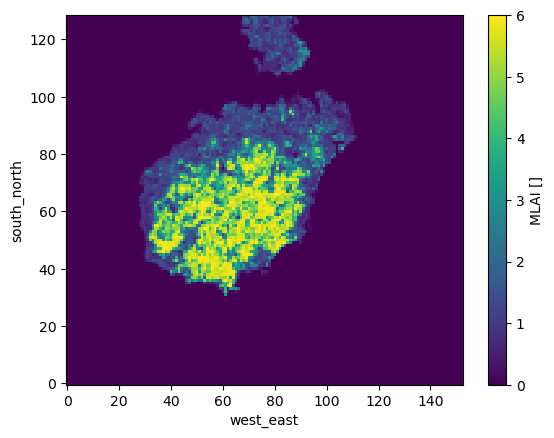

In [25]:
ds['MLAI'].isel(Time=0,months_per_year_stag=8).plot()
plt.show()

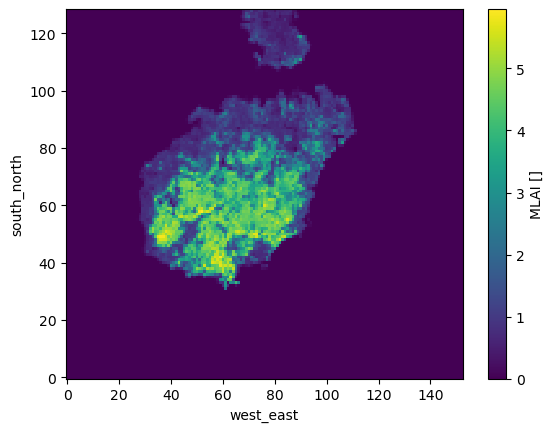

In [30]:
import xarray as xr
import matplotlib.pyplot as plt
# 读取 wrfbiochemi_d03 文件
file_path=r'D:\HPC_Projects\WRF-CMAQ\20260630\wrfbiochemi_to_cmaq\wrfbiochemi_d03'
ds=xr.open_dataset(file_path)
ds['MLAI'].isel(Time=0,months_per_year_stag=1).plot()
plt.show()

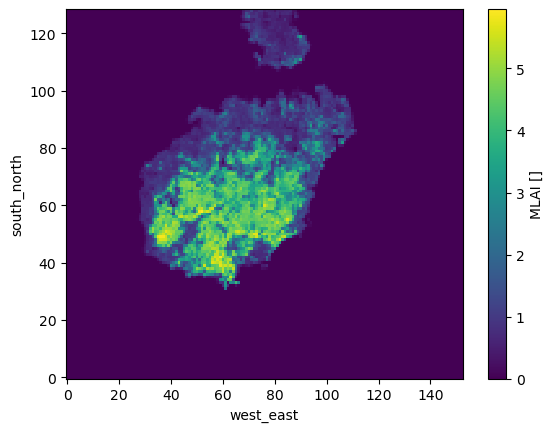

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
# 读取 wrfbiochemi_d03 文件
file_path=r'D:\HPC_Projects\WRF-CMAQ\20260630\wrfbiochemi_to_cmaq\wrfbiochemi_d03_new'
ds=xr.open_dataset(file_path)
ds['MLAI'].isel(Time=0,months_per_year_stag=1).plot()
plt.show()

In [12]:
ds.close()